In [4]:
from google.colab import drive
drive.mount('/content/drive')
#below where the file is in gdrive, change with yours

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# import all necessary libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
import random
from sklearn.metrics import confusion_matrix
import seaborn as sns
import math
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib.image import imread
import os
import shutil
from sklearn.model_selection import train_test_split
import urllib.request
from PIL import Image
import requests
from io import BytesIO
import numpy as np

In [6]:
df_GT = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Data/ISIC_2020_Training_GroundTruth_v2.csv')
df_GT

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0
...,...,...,...,...,...,...,...,...,...
33121,ISIC_9999134,IP_6526534,IL_2076932,male,50.0,torso,unknown,benign,0
33122,ISIC_9999320,IP_3650745,IL_6891604,male,65.0,torso,unknown,benign,0
33123,ISIC_9999515,IP_2026598,IL_6364820,male,20.0,lower extremity,unknown,benign,0
33124,ISIC_9999666,IP_7702038,IL_6048457,male,50.0,lower extremity,unknown,benign,0


In [7]:
# Fix: Use a list of column names (double brackets) to select multiple columns
name = df_GT[["image_name", "benign_malignant"]]
name.head()

,image_name,benign_malignant
0,ISIC_2637011,benign
1,ISIC_0015719,benign
2,ISIC_0052212,benign
3,ISIC_0068279,benign
4,ISIC_0074268,benign


In [8]:
name.shape

(33126, 2)

In [9]:
training_file = "/data/images_new/train"

In [10]:
test_file = "/data/images_new/test"

In [11]:
import os
import shutil

def organize_images_into_classes(source_image_dir, target_base_dir, label_df):
    organized_path = os.path.join(target_base_dir, 'organized_data')
    benign_path = os.path.join(organized_path, 'benign')
    malignant_path = os.path.join(organized_path, 'malignant')

    # 1. Immediate Cache Check
    if os.path.exists(benign_path) and os.path.exists(malignant_path):
        b_count = len(os.listdir(benign_path))
        m_count = len(os.listdir(malignant_path))
        if b_count > 0 or m_count > 0:
            print(f"Cache Found: Data already exists in {organized_path}")
            print(f"Total Benign: {b_count}")
            print(f"Total Malignant: {m_count}")
            return

    # Create class directories
    os.makedirs(benign_path, exist_ok=True)
    os.makedirs(malignant_path, exist_ok=True)

    # Create lookup map
    label_map = dict(zip(label_df['image_name'], label_df['benign_malignant']))

    # Sort images directly from the source_image_dir
    count = 0
    for root, dirs, files in os.walk(source_image_dir):
        for file in files:
            if file.lower().endswith('.jpg'):
                img_id = os.path.splitext(file)[0]
                if img_id in label_map:
                    label_class = label_map[img_id]
                    src = os.path.join(root, file)
                    dst_dir = os.path.join(organized_path, label_class)
                    os.makedirs(dst_dir, exist_ok=True) # Ensure destination directory exists
                    dst = os.path.join(dst_dir, file)

                    if not os.path.exists(dst):
                        shutil.copy(src, dst)
                        count += 1

    print(f"Organized {count} new images.")
    print(f"Total Benign: {len(os.listdir(benign_path))}")
    print(f"Total Malignant: {len(os.listdir(malignant_path))}")

In [12]:
train_target = "/content/drive/MyDrive/Colab_Notebooks/Data/Skin_image/Skin_train"

In [13]:
test_target = "/content/drive/MyDrive/Colab_Notebooks/Data/Skin_image/Skin_test"

In [14]:
organize_images_into_classes(training_file, train_target, name)

Cache Found: Data already exists in /content/drive/MyDrive/Colab_Notebooks/Data/Skin_image/Skin_train/organized_data
Total Benign: 400
Total Malignant: 467


In [15]:
organize_images_into_classes(test_file,test_target, name)

Cache Found: Data already exists in /content/drive/MyDrive/Colab_Notebooks/Data/Skin_image/Skin_test/organized_data
Total Benign: 100
Total Malignant: 117


In [16]:
train_data_set= "/content/drive/MyDrive/Colab_Notebooks/Data/Skin_image/Skin_train/organized_data"

In [17]:
test_data_set= "/content/drive/MyDrive/Colab_Notebooks/Data/Skin_image/Skin_test/organized_data"

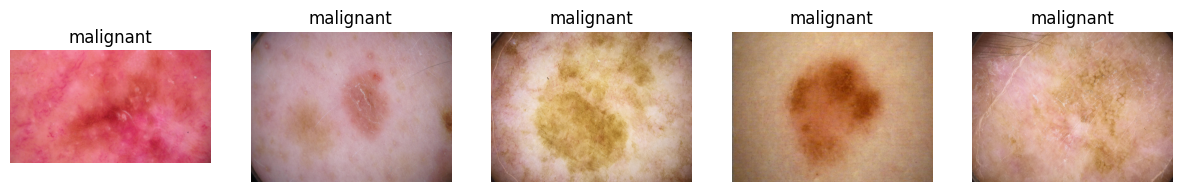

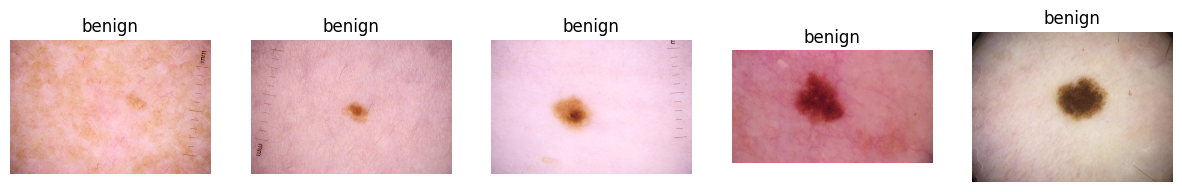

In [18]:
#function to display image from our dataset
def display_sample_images(class_name, dataset_path):
    folder_path = os.path.join(dataset_path, class_name)
    images = random.sample(os.listdir(folder_path), 5)
    plt.figure(figsize=(15, 5))
    for idx, img_name in enumerate(images):
        img = imread(os.path.join(folder_path, img_name))
        plt.subplot(1, 5, idx+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
    plt.show()

display_sample_images('malignant',train_data_set)
display_sample_images('benign',train_data_set)

In [19]:
img_height, img_width = 128, 128
IMG_SHAPE = (img_height, img_width, 3)
NOISE_DIM = 100
batch_size = 32
NUM_CLASSES = 2
EPOCHS = 600
D_LR = 1e-4  # Lower learning rate for Discriminator to prevent it from overpowering the generator
G_LR = 2e-4  # Standard learning rate for Generator
BETA_1 = 0.5

In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values
)

In [21]:
test_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values
)

In [22]:
train_generator = train_datagen.flow_from_directory(
    train_data_set,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'        # Set as training data
)

Found 867 images belonging to 2 classes.


In [23]:
test_generator = test_datagen.flow_from_directory(
    test_data_set,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

Found 217 images belonging to 2 classes.


In [24]:
def build_generator(noise_dim, num_classes, img_shape):
    # Latent vector input
    noise_input = Input(shape=(noise_dim,), name='noise_input')

    # Label input
    label_input = Input(shape=(1,), name='label_input')
    # Use embedding dimension 50
    label_embedding = layers.Embedding(num_classes, 50)(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    # Concatenate noise and label embeddings instead of multiplying to preserve the signal
    merged_input = layers.concatenate([noise_input, label_embedding])

    # First dense layer to upsample merged input
    x = layers.Dense(4 * 4 * 256, use_bias=False)(merged_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Reshape to appropriate dimensions before Conv2DTranspose
    x = layers.Reshape((4, 4, 256))(x)

    # Upsampling layers
    x = layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding='same', use_bias=False)(x) # 4x4 -> 8x8
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False)(x) # 8x8 -> 16x16
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False)(x) # 16x16 -> 32x32
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(32, (5, 5), strides=(2, 2), padding='same', use_bias=False)(x) # 32x32 -> 64x64
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Final Conv2DTranspose to reach exactly 128x128
    # IMPORTANT: use_bias=True allows the generator to shift the baseline color away from 0 (gray)
    x = layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=True, activation='tanh')(x) # 64x64 -> 128x128

    generator = Model([noise_input, label_input], x, name='generator')
    return generator

# Build the generator
generator = build_generator(NOISE_DIM, NUM_CLASSES, IMG_SHAPE)
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │        100 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 150)       │          0 │ noise_input[0][0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4096)      │    614,400 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4096)      │     16,384 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 4096)      │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 4, 4, 256) │          0 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 256) │  1,638,400 │ reshape[0][0]     │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 16,    │    819,200 │ leaky_re_lu_1[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 32,    │    204,800 │ leaky_re_lu_2[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 3,348,807 (12.77 MB)

 Trainable params: 3,339,655 (12.74 MB)

 Non-trainable params: 9,152 (35.75 KB)

Next, we will define the Discriminator model. This model will take an image and a class label and predict whether the image is real or fake.

In [25]:
def build_discriminator(num_classes, img_shape):
    # Image input
    image_input = Input(shape=img_shape, name='image_input')

    # Label input
    label_input = Input(shape=(1,), name='label_input')
    label_embedding = layers.Embedding(num_classes, img_shape[0] * img_shape[1])(label_input) # Embed label to image size
    label_embedding = layers.Reshape((img_shape[0], img_shape[1], 1))(label_embedding) # Reshape to concatenate with image

    # Concatenate image and label embedding
    merged_input = layers.concatenate([image_input, label_embedding], axis=-1) # Concatenate along the channel axis

    # Downsampling layers - Made deeper to match the generator's complexity
    x = layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same')(merged_input)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(512, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    # Flatten and output
    x = layers.Flatten()(x)
    output = layers.Dense(1, activation='sigmoid')(x) # Binary classification (real/fake)

    discriminator = Model([image_input, label_input], output, name='discriminator')
    return discriminator

# Build the discriminator
discriminator = build_discriminator(NUM_CLASSES, IMG_SHAPE)
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 16384)  │     32,768 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 128, 128,  │          0 │ embedding_1[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ image_input[0][0… │
│ (Concatenate)       │ 4)                │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      4,160 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ leaky_re_lu_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │    131,200 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ leaky_re_lu_6[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │    524,544 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 16,    │          0 │ leaky_re_lu_7[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 512) │  2,097,664 │ dropout_2[0][0] 

 Total params: 2,826,689 (10.78 MB)

 Trainable params: 2,824,897 (10.78 MB)

 Non-trainable params: 1,792 (7.00 KB)

Now we will compile both the discriminator and the combined CGAN model. The discriminator is trained to distinguish between real and fake images, while the generator is trained through the combined model to fool the discriminator.

In [26]:
# Compile the discriminator with the lower D_LR
discriminator.compile(optimizer=Adam(learning_rate=D_LR, beta_1=BETA_1),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

# Build the combined GAN model
discriminator.trainable = False # Discriminator weights are frozen during generator training

noise_input = Input(shape=(NOISE_DIM,), name='noise_input_gan')
label_input = Input(shape=(1,), name='label_input_gan')

fake_image = generator([noise_input, label_input])

discriminator_output = discriminator([fake_image, label_input])

# Compile the CGAN model with the standard G_LR
cgan_model = Model([noise_input, label_input], discriminator_output, name='cgan_model')
cgan_model.compile(optimizer=Adam(learning_rate=G_LR, beta_1=BETA_1),
                   loss='binary_crossentropy')

cgan_model.summary()

Model: "cgan_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ noise_input_gan     │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label_input_gan     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generator           │ (None, 128, 128,  │  3,348,807 │ noise_input_gan[… │
│ (Functional)        │ 3)                │            │ label_input_gan[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ discriminator       │ (None, 1)         │  2,826,689 │ generator[0][0],  │
│ (Functional)        │                   │            │ label_input_gan[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,175,496 (23.56 MB)

 Trainable params: 3,339,655 (12.74 MB)

 Non-trainable params: 2,835,841 (10.82 MB)

In [ ]:
def train_cgan(generator, discriminator, cgan_model, train_generator, noise_dim, epochs, batch_size, num_classes, patience_epochs=50, min_delta_loss=0.001):
    best_g_loss = float('inf')
    patience_counter = 0

    # Lists to store history for plotting
    history = {
        'd_loss_real': [], 'd_loss_fake': [],
        'd_acc_real': [], 'd_acc_fake': [],
        'g_loss': []
    }

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")

        # Re-initialize iterator at the start of each epoch
        train_iterator = iter(train_generator)

        d_loss_list_real = []
        d_loss_list_fake = []
        d_acc_list_real = []
        d_acc_list_fake = []
        g_loss_list = []

        for i in range(train_generator.samples // batch_size):
            # Get real images and labels
            real_images, real_labels_binary = next(train_iterator)

            # Convert binary labels to integer labels (0 or 1) for embedding layer
            real_labels_int = real_labels_binary.astype(int)
            real_labels_int = real_labels_int.reshape(-1, 1)

            # Rescale real images from [0, 1] to [-1, 1] to match generator output
            real_images_scaled = (real_images * 2) - 1

            # Get the actual batch size for the current real images
            current_batch_size = real_images.shape[0]

            # Generate fake images
            noise = np.random.normal(0, 1, (current_batch_size, noise_dim))
            fake_labels_int = np.random.randint(0, num_classes, current_batch_size)
            fake_labels_int_reshaped = fake_labels_int.reshape(-1, 1)

            fake_images = generator.predict([noise, fake_labels_int_reshaped], verbose=0)

            # --- LABEL SMOOTHING ---
            real_target_labels = np.ones((current_batch_size, 1)) * 0.9
            fake_target_labels = np.ones((current_batch_size, 1)) * 0.1

            # === Discriminator Training Phase ===
            discriminator.trainable = True # Unfreeze for discriminator training

            # Train discriminator on real images
            d_loss_real, d_acc_real = discriminator.train_on_batch([real_images_scaled, real_labels_int], real_target_labels)
            d_loss_list_real.append(d_loss_real)
            d_acc_list_real.append(d_acc_real)

            # Train discriminator on fake images
            d_loss_fake, d_acc_fake = discriminator.train_on_batch([fake_images, fake_labels_int_reshaped], fake_target_labels)
            d_loss_list_fake.append(d_loss_fake)
            d_acc_list_fake.append(d_acc_fake)

            # === Generator Training Phase ===
            discriminator.trainable = False # Freeze discriminator when training the generator

            # Train generator ONCE (removed loop) to keep balance
            noise = np.random.normal(0, 1, (batch_size, noise_dim))
            gen_labels = np.random.randint(0, num_classes, batch_size)
            gen_labels_reshaped = gen_labels.reshape(-1, 1)

            g_target_labels = np.ones((batch_size, 1))

            g_loss = cgan_model.train_on_batch([noise, gen_labels_reshaped], g_target_labels)
            g_loss_list.append(g_loss)

        # Calculate average losses
        avg_d_loss_real = np.mean(d_loss_list_real)
        avg_d_loss_fake = np.mean(d_loss_list_fake)
        avg_d_acc_real = np.mean(d_acc_list_real)
        avg_d_acc_fake = np.mean(d_acc_list_fake)
        avg_g_loss = np.mean(g_loss_list)

        print(f"  Discriminator (Real): Loss = {avg_d_loss_real:.4f}, Acc = {avg_d_acc_real:.4f}")
        print(f"  Discriminator (Fake): Loss = {avg_d_loss_fake:.4f}, Acc = {avg_d_acc_fake:.4f}")
        print(f"  Generator: Loss = {avg_g_loss:.4f}")

        # Append to history
        history['d_loss_real'].append(avg_d_loss_real)
        history['d_loss_fake'].append(avg_d_loss_fake)
        history['d_acc_real'].append(avg_d_acc_real)
        history['d_acc_fake'].append(avg_d_acc_fake)
        history['g_loss'].append(avg_g_loss)

        # Early Stopping Logic (adjusted patience for GAN stability)
        if avg_g_loss < best_g_loss - min_delta_loss:
            best_g_loss = avg_g_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience_epochs:
                print(f"Early stopping triggered after {epoch + 1} epochs.")
                break

    return history

# Force model building by making a dummy prediction before starting training
import tensorflow as tf
dummy_noise = tf.convert_to_tensor(np.random.normal(0, 1, (batch_size, NOISE_DIM)), dtype=tf.float32)
dummy_labels = tf.convert_to_tensor(np.random.randint(0, NUM_CLASSES, batch_size).reshape(-1, 1), dtype=tf.int32)
_ = generator.predict([dummy_noise, dummy_labels], verbose=0)

# Start training and capture history
history = train_cgan(generator, discriminator, cgan_model, train_generator, NOISE_DIM, EPOCHS, batch_size, NUM_CLASSES)



Epoch 1/600


In [ ]:
# Function to generate and display images for a given class
def generate_and_display_images(generator, noise_dim, num_classes, class_label, num_samples=5):
    noise = np.random.normal(0, 1, (num_samples, noise_dim))
    # Create labels for the specific class
    # Assuming 0 for benign and 1 for malignant, you might need to adjust based on your train_generator.class_indices
    if class_label == 'benign':
        labels = np.zeros(num_samples).reshape(-1, 1).astype(int)
    elif class_label == 'malignant':
        labels = np.ones(num_samples).reshape(-1, 1).astype(int)
    else:
        raise ValueError("Invalid class_label. Must be 'benign' or 'malignant'.")

    generated_images = generator.predict([noise, labels])

    # Rescale images from [-1, 1] to [0, 1] for proper visualization
    generated_images = (generated_images + 1) / 2.0

    # Debugging: Print min/max pixel values after rescaling
    print(f"Min/Max pixel value for {class_label} (rescaled): {generated_images.min():.4f}/{generated_images.max():.4f}")

    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        # Explicitly set vmin and vmax for correct display of float images (0-1 range)
        plt.imshow(generated_images[i], vmin=0, vmax=1)
        plt.title(class_label)
        plt.axis('off')
    plt.suptitle(f'Generated {class_label} Images', fontsize=16)
    plt.show()

### Retraining the CGAN with `tanh` activation in the Generator

### Generated Images After Retraining

In [ ]:
# Generate and display images for 'benign' class
generate_and_display_images(generator, NOISE_DIM, NUM_CLASSES, 'benign', num_samples=5)

# Generate and display images for 'malignant' class
generate_and_display_images(generator, NOISE_DIM, NUM_CLASSES, 'malignant', num_samples=5)

### Training History After Retraining

In [ ]:
# Plotting training history
plt.figure(figsize=(12, 6))

# Plot Discriminator Loss
plt.subplot(1, 2, 1)
plt.plot(history['d_loss_real'], label='Discriminator Loss (Real)')
plt.plot(history['d_loss_fake'], label='Discriminator Loss (Fake)')
plt.plot(history['g_loss'], label='Generator Loss')
plt.title('Losses Over Epochs (New Training)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Discriminator Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['d_acc_real'], label='Discriminator Accuracy (Real)')
plt.plot(history['d_acc_fake'], label='Discriminator Accuracy (Fake)')
plt.title('Discriminator Accuracy Over Epochs (New Training)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Plotting training history
plt.figure(figsize=(12, 6))

# Plot Discriminator Loss
plt.subplot(1, 2, 1)
plt.plot(history['d_loss_real'], label='Discriminator Loss (Real)')
plt.plot(history['d_loss_fake'], label='Discriminator Loss (Fake)')
plt.plot(history['g_loss'], label='Generator Loss')
plt.title('Losses Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Discriminator Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['d_acc_real'], label='Discriminator Accuracy (Real)')
plt.plot(history['d_acc_fake'], label='Discriminator Accuracy (Fake)')
plt.title('Discriminator Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Plot losses
plt.figure(figsize=(8,5))
plt.plot(history['d_loss_real'], label='Discriminator Loss (Real)', color='blue')
plt.plot(history['d_loss_fake'], label='Discriminator Loss (Fake)', color='cyan')
plt.plot(history['g_loss'], label='Generator Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CGAN Training Loss')
plt.legend()
plt.grid(True)
plt.show()